## Exploring the use of LSTM (long-short term memory) on our data

Adapting code from geeks for geeks: https://www.geeksforgeeks.org/deep-learning/long-short-term-memory-lstm-rnn-in-tensorflow/

Using tensorflow for LSTM tools

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

Loading real time market and day-ahead market data

In [19]:
data_path = '../data-pull/combined_data/'

In [20]:
dam = pd.read_parquet(f'{data_path}dam_data_2023_2026.parquet')
rtm = pd.read_parquet(f'{data_path}rtm_data_2023_2026.parquet')


Merge both datasets into one dataframe

In [28]:
data = pd.merge(
    dam,
    rtm,
    on=['interval_end_utc'],
    suffixes=('_dam', '_rtm')
)
data = data.sort_values('interval_end_utc')

Transform/scale the data

In [29]:
lmp_dam = data['lmp_dam'].astype(float).values.reshape(-1, 1)
lmp_rtm = data['lmp_rtm'].astype(float).values.reshape(-1, 1) #target/label

scaler_dam = MinMaxScaler(feature_range=(0,1))
scaled_dam_data = scaler_dam.fit_transform(lmp_dam)

scaler_rtm = MinMaxScaler(feature_range=(0,1))
scaled_rtm_data = scaler_rtm.fit_transform(lmp_rtm)

Split the transformed data into training and testing sets

In [ ]:
window_size = 12
X = []
y = []
target_dates = []

for i in range(window_size, len(data)):
    X.append(scaled_dam_data[i - window_size:i, 0])
    y.append(scaled_rtm_data[i, 0])
    target_dates.append(
        data['interval_end_utc'].iloc[i]
    )

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, target_dates, test_size=0.2, shuffle=False
)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

Build the LSTM model

In [34]:
model = Sequential()
model.add(LSTM(units=64, return_sequences=True,
          input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

Train the model on our data

In [35]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

predictions = model.predict(X_test)
predictions = scaler_rtm.inverse_transform(predictions).flatten()
y_test = scaler_rtm.inverse_transform(y_test.reshape(-1,1)).flatten()

rmse = np.sqrt(np.mean((y_test - predictions)**2))
print(f'RMSE: {rmse:.2f}')

Epoch 1/100


677/677 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 3.3189e-05 - val_loss: 1.3594e-05
Epoch 2/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 2.9772e-05 - val_loss: 1.2131e-05
Epoch 3/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 2.9289e-05 - val_loss: 1.2775e-05
Epoch 4/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 2.8776e-05 - val_loss: 1.2564e-05
Epoch 5/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 2.8455e-05 - val_loss: 1.1960e-05
Epoch 6/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 2.8270e-05 - val_loss: 1.2312e-05
Epoch 7/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 2.8280e-05 - val_loss: 1.1898e-05
Epoch 8/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 2.8279e-05 - val_loss: 1.1854e-05
Epoch 9/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 2.8202e-05 - val_loss: 1.1806e-05
Epoch 10/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 2.8034e-05 - val_loss: 1.1840e-05
Epoch 11/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss:

Compare test data with predictions

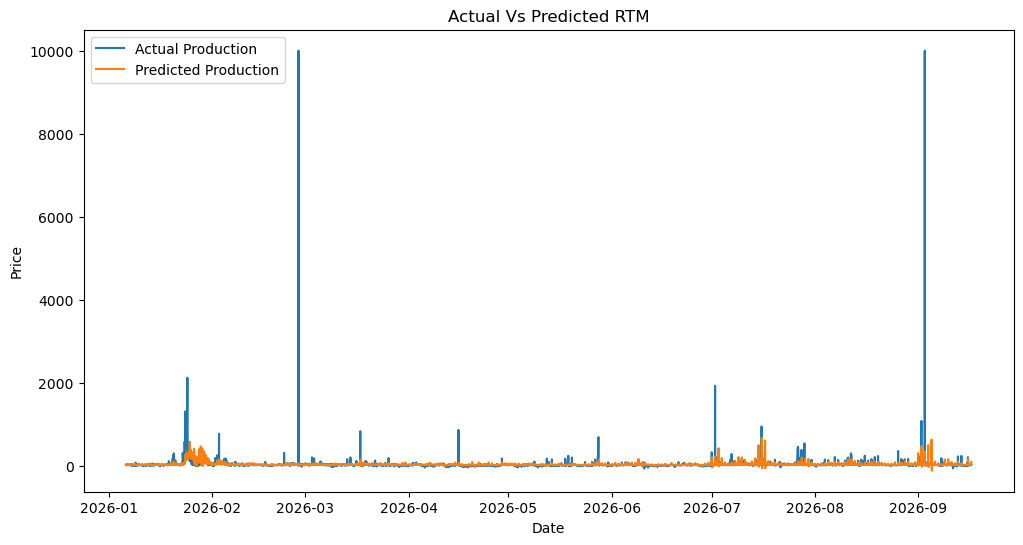

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test, label='Actual Production')
plt.plot(dates_test, predictions, label='Predicted Production')
plt.title('Actual Vs Predicted RTM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

The error on this model is excedingly large, likely due to the insane outliers

Scaling the graph down to compare patterns

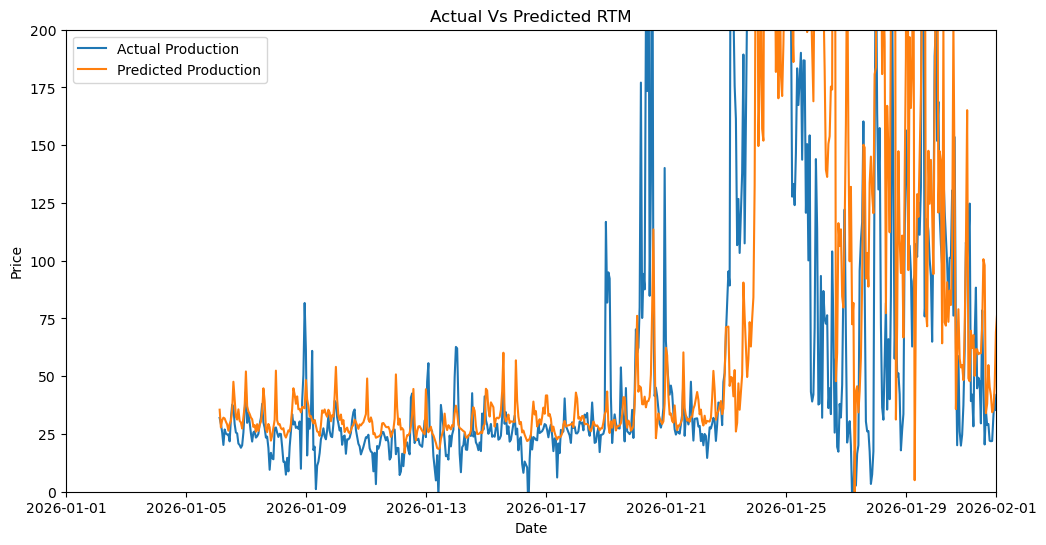

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test, label='Actual Production')
plt.plot(dates_test, predictions, label='Predicted Production')
plt.title('Actual Vs Predicted RTM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.ylim(0, 200)
plt.xlim(
    pd.Timestamp('2026-01-01'),
    pd.Timestamp('2026-02-01')
)
plt.legend()
plt.show()

Captures the up and down pattern in price, but not fantastically